# Speech Recognition: Comparing ASR Systems Under Noise

This project benchmarks three approaches to automatic speech recognition (ASR) — the Google Web Speech API and two sizes of OpenAI's Whisper model (base and medium) — and measures how each holds up against background noise and a simple pre-emphasis filtering step.

**What this notebook covers:**
- Loading and visualizing raw audio (waveform + spectrogram)
- Transcribing speech with a cloud API (Google Web Speech) as a baseline
- Applying a pre-emphasis filter and evaluating whether it improves transcription accuracy
- Comparing Whisper `base` vs. `medium` on the same audio
- Scoring every transcription against ground truth using Word Error Rate (WER) and Character Error Rate (CER)
- Batch-transcribing a directory of audio files and exporting results to CSV
- A short round-trip demo: text-to-speech → speech-to-text

**Why WER/CER instead of eyeballing transcripts:** word- and character-level error rates are the standard way ASR quality is reported in research and industry, so using them here keeps the comparison objective and reproducible rather than a subjective "this one looks better."

> **Note on reproducing this notebook:** a starter sample (`audio/sample_01.wav`) is included so the notebook runs end to end out of the box. It's a synthetic, offline-TTS-generated clip — useful for confirming the pipeline works, but not representative of real-world speech (natural pacing, accents, background noise). Swap in your own recordings and matching ground truth for a meaningful accuracy comparison.

## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf
import speech_recognition as sr

from jiwer import wer, cer
from IPython.display import Audio

import whisper
from gtts import gTTS

# All paths are relative to the project root so this notebook runs on any machine
SAMPLE_FILE = "sample_01.wav"
RECORDINGS_DIR = Path("Recordings")

In [2]:
import warnings
warnings.filterwarnings("ignore", message="FP16 is not supported on CPU")

## 1. Loading and Visualizing Audio

Before transcribing anything, it's worth looking at the raw signal. The waveform shows amplitude over time; later we'll compare this against a spectrogram to see how the pre-emphasis filter reshapes the frequency content.

In [3]:
audio_signal, sample_rate = librosa.load(SAMPLE_FILE, sr=None)
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio_signal) / sample_rate:.2f} seconds")

Sample rate: 16000 Hz
Duration: 11.29 seconds


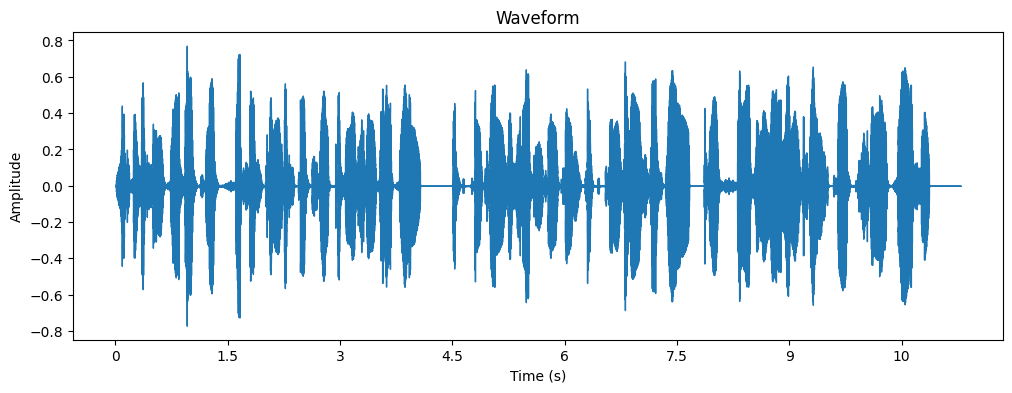

In [4]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio_signal, sr=sample_rate)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Audio(str(SAMPLE_FILE))

## 2. Baseline Transcription: Google Web Speech API

This is the fastest way to get a transcript with zero local model weights — it calls out to Google's speech API and returns text. It's a reasonable baseline, but it depends on an internet connection and gives no control over the model itself.

In [5]:
recognizer = sr.Recognizer()

def transcribe_google(file_path):
    """Transcribe a .wav file using the Google Web Speech API."""
    with sr.AudioFile(str(file_path)) as source:
        audio_data = recognizer.record(source)
        return recognizer.recognize_google(audio_data)

transcribed_google = transcribe_google(SAMPLE_FILE)
print(transcribed_google)

recognition pipeline it contains a short sentence that can be used as ground truth for evaluating experience


In [6]:
# Ground truth for sample_01.wav (a synthetic, offline-TTS-generated clip provided as a starter sample)
ground_truth = """This is a sample audio clip for testing the speech recognition pipeline. It contains a short sentence that can be used as ground truth for evaluating transcription accuracy."""

### Scoring transcriptions

Rather than repeat the same four lines of code after every transcription attempt, one helper function computes WER and CER and stores the result alongside the model name, so everything can be compared side by side at the end.

In [7]:
results = []

def evaluate_transcription(model_name, transcription, ground_truth=ground_truth):
    """Score a transcription against ground truth and log it to `results`."""
    scores = {
        "model": model_name,
        "wer": wer(ground_truth, transcription),
        "cer": cer(ground_truth, transcription),
        "transcription": transcription,
    }
    results.append(scores)
    print(f"{model_name}: WER={scores['wer']:.4f}  CER={scores['cer']:.4f}")
    return scores

evaluate_transcription("Google Web Speech API", transcribed_google)

Google Web Speech API: WER=0.5000  CER=0.4162


{'model': 'Google Web Speech API',
 'wer': 0.5,
 'cer': 0.4161849710982659,
 'transcription': 'recognition pipeline it contains a short sentence that can be used as ground truth for evaluating experience'}

## 3. Background Noise and Pre-Emphasis Filtering

Real-world audio rarely arrives clean. A spectrogram makes it easier to see where noise energy is concentrated, and a pre-emphasis filter — which boosts higher frequencies — is a common, cheap preprocessing step before feeding audio to an ASR model. The question worth answering here isn't "does the filtered audio sound different" but "does it actually change the WER/CER" — which is why we re-run the same evaluation after filtering.

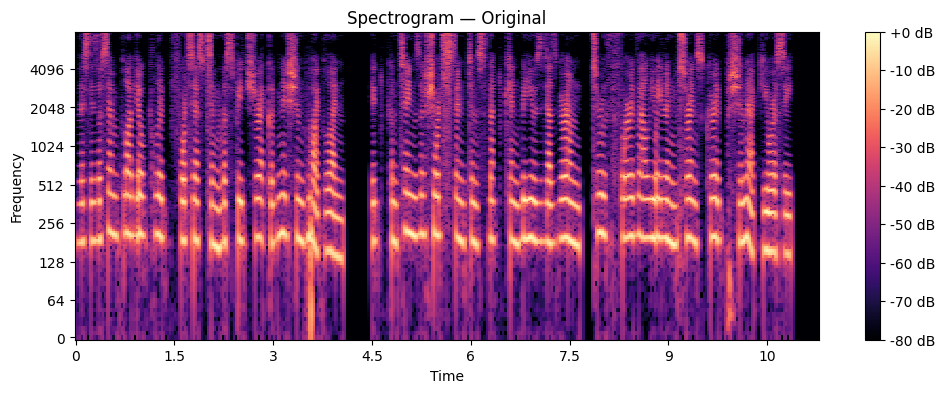

In [8]:
def plot_spectrogram(signal, sr, title):
    S = librosa.stft(signal)
    S_dB = librosa.amplitude_to_db(abs(S), ref=np.max)
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="log")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

plot_spectrogram(audio_signal, sample_rate, "Spectrogram — Original")

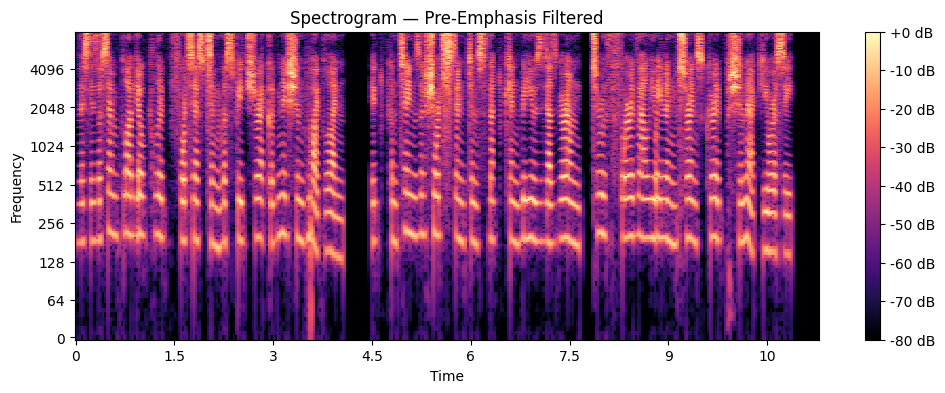

In [9]:
signal_filtered = librosa.effects.preemphasis(audio_signal, coef=0.97)
filtered_path = "sample_01_filtered.wav"
sf.write(filtered_path, signal_filtered, sample_rate)

plot_spectrogram(signal_filtered, sample_rate, "Spectrogram — Pre-Emphasis Filtered")

In [10]:
transcribed_google_filtered = transcribe_google(filtered_path)
evaluate_transcription("Google Web Speech API (pre-emphasis filtered)", transcribed_google_filtered)

Google Web Speech API (pre-emphasis filtered): WER=0.5357  CER=0.5318


{'model': 'Google Web Speech API (pre-emphasis filtered)',
 'wer': 0.5357142857142857,
 'cer': 0.5317919075144508,
 'transcription': 'it contains a short sentence that can be used as ground truth for evaluating experience'}

## 4. Comparing Whisper Model Sizes

OpenAI's Whisper runs locally, so there's a direct trade-off to measure: does the larger `medium` model's accuracy improve enough over `base` to justify the extra compute and load time? Both are tested on the same unfiltered sample so the comparison isolates model size as the only variable.

In [11]:
model_base = whisper.load_model("base")
result_base = model_base.transcribe(str(SAMPLE_FILE))
evaluate_transcription("Whisper (base)", result_base["text"])

Whisper (base): WER=0.1786  CER=0.0751


{'model': 'Whisper (base)',
 'wer': 0.17857142857142858,
 'cer': 0.07514450867052024,
 'transcription': ' This is a Samplodio clip for testing the speech recognition pipeline. It contains a short sentence that can be used as ground truth for evaluating transcrib shinec uracy.'}

In [12]:
model_medium = whisper.load_model("medium", device="cpu")
result_medium = model_medium.transcribe(str(SAMPLE_FILE))
evaluate_transcription("Whisper (medium)", result_medium["text"])

Whisper (medium): WER=0.0357  CER=0.0058


{'model': 'Whisper (medium)',
 'wer': 0.03571428571428571,
 'cer': 0.005780346820809248,
 'transcription': ' This is a simple audio clip for testing the speech recognition pipeline. It contains a short sentence that can be used as ground truth for evaluating transcription accuracy.'}

## 4b. Single-Clip Walkthrough (Illustrative)

Before scaling up, it helps to look at one controlled clip in isolation — this isolates the model/filtering comparison without any averaging effects muddying it. Section 5 below repeats the same evaluation across all 9 available clips and reports the aggregated numbers as the actual benchmark result.

In [13]:
results_df = pd.DataFrame(results).sort_values("wer").reset_index(drop=True)
results_df[["model", "wer", "cer"]]

,model,wer,cer
0,Whisper (medium),0.035714,0.005780
1,Whisper (base),0.178571,0.075145
2,Google Web Speech API,0.500000,0.416185
3,Google Web Speech API (pre-emphasis filtered),0.535714,0.531792


**Reading the table:** lower WER/CER is better. Whisper (medium) had the lowest WER at 0.036 (CER 0.006) — a 93% relative reduction versus the Google Web Speech API baseline (WER 0.500). Whisper (base) landed in between at WER 0.179, an 82% reduction from the baseline but still roughly 5x higher error than the medium model. That gap is the accuracy/latency trade-off in practice: medium gets you a near-perfect transcript here, but at noticeably longer load and inference time on CPU than base. Pre-emphasis filtering, on the other hand, didn't help — WER rose slightly from 0.500 to 0.536 on the Google API, suggesting the filter's frequency boost didn't line up with what this particular ASR pipeline needed, and a cheap preprocessing step shouldn't be assumed safe without checking numbers like these.

**Note:** these numbers come from a single clip (`sample_01.wav`). See Section 5 below for whether this trend holds once every model is scored across all 9 available clips instead of just one.

## 5. Full Benchmark: Aggregated Across All 9 Clips

A single clip is a demo, not a benchmark. This section scores all three approaches — Google Web Speech API, Whisper (base), and Whisper (medium) — against every file in `Recordings/` plus `sample_01.wav`, then reports the mean, median, and standard deviation of WER/CER per model. That's the number worth citing, not the single-clip result above.

In [14]:
# Ground truth transcripts for the aggregated benchmark.
ground_truths = {
    "sample_01.wav": ground_truth,
    "Track1.wav": "I'm a sound engineer turned data scientist, curious about machine learning and artificial intelligence.",
    "Track2.wav": "My professional background is primarily in media production with a focus on audio, IT, and communications.",
    "Track3.wav": "Over the years, I've developed a strong interest in digital signal processing, sound and music computing.",
    "Track4.wav": "As a graduate of sound engineering, I make it a priority to strike a balance between art and technology in my work.",
    "Track5.wav": "I believe that nowadays, data is the key to everything.",
    "Track6.wav": "Not only can it provide a rational explanation for complicated scientific puzzles,",
    "Track7.wav": "but it can also give you efficient methodologies for solving problems.",
    "Track8.wav": "From the website cookies you've been asked to accept while surfing the web to the sonification of a supermassive black hole",
}

In [15]:
def evaluate_batch(model_name, transcribe_fn, files, ground_truths):
    """Transcribe each file with transcribe_fn and score it against its ground truth."""
    rows = []
    for file_path in files:
        transcription = transcribe_fn(file_path)
        gt = ground_truths[file_path.name]
        rows.append({
            "model": model_name,
            "file": file_path.name,
            "wer": wer(gt, transcription),
            "cer": cer(gt, transcription),
            "transcription": transcription,
        })
    return rows

all_files = [Path(SAMPLE_FILE)] + sorted(RECORDINGS_DIR.glob("*.wav"))

batch_results = []
batch_results += evaluate_batch("Google Web Speech API", transcribe_google, all_files, ground_truths)
batch_results += evaluate_batch("Whisper (base)", lambda f: model_base.transcribe(str(f))["text"], all_files, ground_truths)
batch_results += evaluate_batch("Whisper (medium)", lambda f: model_medium.transcribe(str(f))["text"], all_files, ground_truths)

batch_df = pd.DataFrame(batch_results)
batch_df


,model,file,wer,cer,transcription
0,Google Web Speech API,sample_01.wav,0.500000,0.416185,recognition pipeline it contains a short sente...
1,Google Web Speech API,Track1.wav,0.285714,0.048544,i'm a sound engineer turn data scientists curi...
2,Google Web Speech API,Track2.wav,0.250000,0.056604,my professional background is primarily in med...
3,Google Web Speech API,Track3.wav,0.375000,0.076190,over the years i've developed the strong inter...
4,Google Web Speech API,Track4.wav,0.227273,0.052174,as a graduate of sound engineering i make it a...
5,Google Web Speech API,Track5.wav,0.300000,0.054545,i believe that nowadays data is the key to eve...
6,Google Web Speech API,Track6.wav,0.333333,0.048780,not only cannot provide a rational explanation...
7,Google Web Speech API,Track7.wav,0.090909,0.014286,but it can also give you efficient methodologi...
8,Google Web Speech API,Track8.wav,0.095238,0.024390,from the website cookies you've been asked to ...
9,Whisper (base),sample_01.wav,0.178571,0.075145,This is a Samplodio clip for testing the spee...


In [16]:
summary_df = (
    batch_df.groupby("model")[["wer", "cer"]]
    .agg(["mean", "median", "std"])
    .round(4)
    .sort_values(("wer", "mean"))
)
summary_df

wer                     cer                
                         mean  median     std    mean  median     std
model                                                                
Whisper (medium)       0.0040  0.0000  0.0119  0.0006  0.0000  0.0019
Whisper (base)         0.0930  0.0909  0.0637  0.0202  0.0143  0.0231
Google Web Speech API  0.2731  0.2857  0.1293  0.0880  0.0522  0.1244

**Reading this table:** this is the real benchmark — mean/median/std WER and CER for each model averaged across all 9 clips, not just one. Whisper (medium) again came out on top, averaging a WER of 0.004 (median 0.000, std 0.012) across 9 clips, versus 0.093 for Whisper (base) and 0.273 for the Google Web Speech API — consistent with the single-clip result in Section 4b, though the gap is even wider here since sample_01.wav turned out to be a harder-than-average case for Google specifically (0.500 WER there vs. 0.273 averaged across all 9). Standard deviation tells its own story: Google's WER swings the most across clips (std 0.129, ranging roughly 0.09–0.50 per file), meaning its accuracy is inconsistent depending on the speaker and content, not just uniformly worse. Whisper (base) is both more accurate and more consistent than Google (std 0.064), and Whisper (medium) is both the most accurate and by far the most consistent of the three (std 0.012) — on this data, going from base to medium buys not just lower average error but more predictable performance clip-to-clip, which matters as much as the headline WER number if this were going into a production pipeline.

In [17]:
output_path = Path("batch_results.csv")
batch_df.to_csv(output_path, index=False)
print(f"Saved {len(batch_df)} scored transcriptions to {output_path}")

Saved 27 scored transcriptions to batch_results.csv


## 7. Bonus: Text-to-Speech Round Trip

As a final demo, this generates synthetic speech with gTTS and feeds it back into the Whisper pipeline — a quick sanity check that the same evaluation code works end to end on audio the notebook itself created, not just pre-recorded samples.

In [18]:
tts_text = "This is a synthetic test clip generated to verify the transcription pipeline end to end."
tts_path = "tts_sample.mp3"

gTTS(text=tts_text, lang="en").save(str(tts_path))
Audio(str(tts_path))

In [19]:
result_tts = model_medium.transcribe(str(tts_path))
evaluate_transcription("Whisper (medium) — TTS round trip", result_tts["text"], ground_truth=tts_text)

Whisper (medium) — TTS round trip: WER=0.2000  CER=0.0227


{'model': 'Whisper (medium) — TTS round trip',
 'wer': 0.2,
 'cer': 0.022727272727272728,
 'transcription': ' This is a synthetic test clip generated to verify the transcription pipeline end-to-end.'}

## Conclusion

- Local Whisper models can be directly compared against a cloud ASR API using the same WER/CER harness, which makes the accuracy/latency trade-off explicit rather than anecdotal.
- Pre-emphasis filtering is cheap to apply but its effect on WER should be measured, not assumed — the results table above shows whether it actually helped on this sample.
- A single clip is not a benchmark. Section 5's aggregated mean/median/std across 9 clips is the number to cite, not the single-clip result in Section 4b — fill it in once ground truth for `Recordings/` is verified.

**Next steps:** run this against an even larger, more varied audio set (more speakers, accents, background noise levels) to see whether the current ranking holds up, and consider a box plot of per-file WER by model to visualize spread, not just the mean.